In [1]:
import numpy as np
import pandas as pd

# pandas w/ support for geojson files
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load GeoJSON file
geo_data = gpd.read_file('data/structure_data_filtered_new.geojson')

geo_data.head(5)


,DAMAGE,CITY,CALFIREUNIT,COUNTY,INCIDENTNAME,INCIDENTSTARTDATE,STRUCTURETYPE,STRUCTURECATEGORY,ROOFCONSTRUCTION,EAVES,...,FENCEATTACHEDTOSTRUCTURE,FIRENAME,ASSESSEDIMPROVEDVALUE,YEARBUILT,SITEADDRESS,Latitude,Longitude,INCIDENTSTARTYEAR,DECADEBUILT,geometry
0,No Damage,Winters,LNU,Solano,Quail,"Sat, 06 Jun 2020 00:00:00 GMT",Single Family Residence Multi Story,Single Residence,Asphalt,Unenclosed,...,No Fence,Quail,510000.0,1997.0,8376 QUAIL CANYON RD VACAVILLE CA 95688,38.474960,-122.044465,2020.0,1990.0,POINT (-13585927.697 4646740.75)
1,Affected (1-9%),Winters,LNU,Solano,Quail,"Sat, 06 Jun 2020 00:00:00 GMT",Single Family Residence Single Story,Single Residence,Asphalt,Unenclosed,...,Combustible,Quail,573052.0,1980.0,8402 QUAIL CANYON RD VACAVILLE CA 95688,38.477442,-122.043252,2020.0,1980.0,POINT (-13585792.707 4647093.599)
2,No Damage,Winters,LNU,Solano,Quail,"Sat, 06 Jun 2020 00:00:00 GMT",Single Family Residence Single Story,Single Residence,Asphalt,Enclosed,...,No Fence,Quail,350151.0,2004.0,8430 QUAIL CANYON RD VACAVILLE CA 95688,38.479358,-122.044585,2020.0,2000.0,POINT (-13585941.007 4647366.034)
3,No Damage,Winters,LNU,Solano,Quail,"Sat, 06 Jun 2020 00:00:00 GMT",Single Family Residence Single Story,Single Residence,Asphalt,Unenclosed,...,No Fence,Quail,134880.0,1981.0,3838 PUTAH CREEK RD WINTERS CA 95694,38.487313,-122.015115,2020.0,1980.0,POINT (-13582660.52 4648497.399)
4,No Damage,Winters,LNU,Solano,Quail,"Sat, 06 Jun 2020 00:00:00 GMT",Single Family Residence Single Story,Single Residence,Tile,Enclosed,...,No Fence,Quail,346648.0,1980.0,3830 PUTAH CREEK RD WINTERS CA 95694,38.485636,-122.016122,2020.0,1980.0,POINT (-13582772.601 4648258.826)


In [4]:
geo_data.columns

Index(['DAMAGE', 'CITY', 'CALFIREUNIT', 'COUNTY', 'INCIDENTNAME',
       'INCIDENTSTARTDATE', 'STRUCTURETYPE', 'STRUCTURECATEGORY',
       'ROOFCONSTRUCTION', 'EAVES', 'VENTSCREEN', 'EXTERIORSIDING',
       'WINDOWPANE', 'DECKPORCHONGRADE', 'PATIOCOVERCARPORT',
       'FENCEATTACHEDTOSTRUCTURE', 'FIRENAME', 'ASSESSEDIMPROVEDVALUE',
       'YEARBUILT', 'SITEADDRESS', 'Latitude', 'Longitude',
       'INCIDENTSTARTYEAR', 'DECADEBUILT', 'geometry'],
      dtype='object')

In [4]:
geo_data['YEARBUILT'].value_counts()

YEARBUILT
0.0       10606
1947.0     2449
1948.0     2026
1950.0     1948
1978.0     1815
          ...  
1891.0        2
1852.0        2
1884.0        1
1543.0        1
1853.0        1
Name: count, Length: 158, dtype: int64

In [5]:
# set nonsensical year values to nan
geo_data.loc[geo_data['YEARBUILT'] < 250.0] = np.nan

In [6]:
geo_data['YEARBUILT'].agg(['min', 'max'])

min    1543.0
max    2022.0
Name: YEARBUILT, dtype: float64

<Axes: >

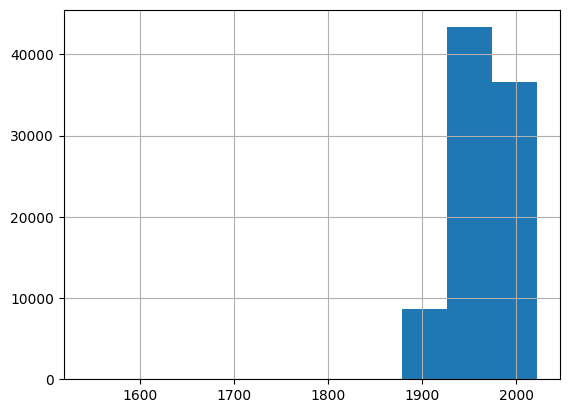

In [7]:
geo_data['YEARBUILT'].hist()

In [9]:
geo_data['DECADEBUILT'] = (geo_data['YEARBUILT'] // 10) * 10
geo_data['DECADEBUILT'] = ['Before 1900' if x < 1900 else x for x in geo_data['DECADEBUILT']]
geo_data['DECADEBUILT'].value_counts()

DECADEBUILT
1970.0         13251
1950.0         11620
1980.0         11164
1940.0         10961
1960.0         10022
1990.0          8608
2000.0          6861
1920.0          6451
1930.0          3623
1900.0          2232
2010.0          2223
1910.0          1232
Before 1900      329
2020.0            69
Name: count, dtype: int64

In [10]:
geo_data.columns

Index(['DAMAGE', 'CITY', 'CALFIREUNIT', 'COUNTY', 'INCIDENTNAME',
       'INCIDENTSTARTDATE', 'STRUCTURETYPE', 'STRUCTURECATEGORY',
       'ROOFCONSTRUCTION', 'EAVES', 'VENTSCREEN', 'EXTERIORSIDING',
       'WINDOWPANE', 'DECKPORCHONGRADE', 'PATIOCOVERCARPORT',
       'FENCEATTACHEDTOSTRUCTURE', 'FIRENAME', 'ASSESSEDIMPROVEDVALUE',
       'YEARBUILT', 'SITEADDRESS', 'Latitude', 'Longitude',
       'INCIDENTSTARTYEAR', 'geometry', 'DECADEBUILT'],
      dtype='object')

In [11]:
geo_data.to_file('data/structure_data_filtered_new.geojson', driver='GeoJSON')